# Notebook 5 — Movement Prediction & Bot Archetypes

**Dataset:** 741 battles, 51 bots, ~48M tick rows (50-bot rumble, 35 rounds/battle)

**Questions:**
1. Can we predict opponent position N ticks ahead? (linear vs. circular vs. ML)
2. Do movement patterns differ by bot archetype? (clustering bots by behavior)
3. Are movement patterns periodic/predictable? (autocorrelation analysis)
4. Does opponent movement change across rounds? (adaptation detection)

**Key concepts:**
- **Lateral velocity** = opponent speed perpendicular to the line between the two robots. This is what makes a robot hard to hit — the faster they move sideways, the more a bullet needs to lead.
- **Heading delta** = how fast the opponent is turning (radians per tick). Combined with velocity, this predicts whether they'll continue straight or curve.
- **Autocorrelation** = does a signal repeat itself? If `lateral_velocity` at time t correlates with `lateral_velocity` at time t+20, the opponent has a ~20-tick movement pattern.
- **Archetype** = a cluster of bots that move similarly. Wave surfers, oscillators, rammers, etc.

In [1]:
# Stratified per-robot sampling — full dataset is ~20 GB, can't fit in RAM.
import sys; sys.path.insert(0, '.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from _loader import (build_robot_index, load_stratified, attach_opponent_bot,
                     numeric_feature_cols, drop_redundant_features,
                     CSV_ROOT_DEFAULT)

sns.set_theme(style='whitegrid', palette='muted')
CSV_ROOT = CSV_ROOT_DEFAULT

selection = build_robot_index(max_robots=50, battles_per_robot=5, seed=42)
print(f"{len(selection)} (battle, observer-bot) pairs selected.")


Indexed 3888 ticks.csv files across 50 distinct robots from 1 root(s).
Selected 50 robots × ~5 battles = 250 (battle, robot) pairs to load.
250 (battle, observer-bot) pairs selected.


## 1. Data Loading

48M rows won't fit in memory at once. Strategy:
- Load a **stratified sample**: pick 5 random battles per bot (as the observed bot), giving ~50 × 5 = 250 perspectives
- For autocorrelation and adaptation analysis, load full battles for selected bots
- Each ticks.csv has ~30K rows (35 rounds × ~800 ticks/round)

In [2]:
# Show how many distinct observer bots ended up in the selection.
observer_counts = {}
for battle_id, bot in selection:
    observer_counts[bot] = observer_counts.get(bot, 0) + 1
print(f'Bots in sample: {len(observer_counts)}')
for name in sorted(observer_counts):
    print(f'  {name}: {observer_counts[name]} battles')


Bots in sample: 50
  Ali 0.4.9: 5 battles
  Ascendant 1.2.27: 5 battles
  BeepBoop 2.0: 5 battles
  BlackBox 0.0.2: 5 battles
  CHCl3 1.4.2: 5 battles
  Cardigan 1.09: 5 battles
  CassiusClay 2rho.02no: 5 battles
  Chalk 2.6.Be: 5 battles
  Combat 3.25.0: 5 battles
  CunobelinDC 1.2: 5 battles
  Cyanide 1.90: 5 battles
  Diamond 1.8.22: 5 battles
  Domogled 1.2: 5 battles
  Dookious 1.573c: 5 battles
  DrussGT 3.1.7: 5 battles
  Engineer 0.5.4: 5 battles
  Firebird 0.25: 5 battles
  Firestarter 2.0f: 5 battles
  Foilist 1.3.1: 5 battles
  Garm 0.9u: 5 battles
  Gilgalad 1.99.5c: 5 battles
  GresSuffurd 0.4.13: 5 battles
  Holden 1.13a: 5 battles
  Horizon 1.2.2: 5 battles
  Hydra 0.21: 5 battles
  Knight 0.6.28: 5 battles
  Midboss 1q.fast: 5 battles
  Nene 1.0.5: 5 battles
  Neuromancer 7.12: 5 battles
  Phoenix 1.02: 5 battles
  PowerHouse 1.7e3: 5 battles
  Pris 0.92: 5 battles
  PulsarMax 0.8.9: 5 battles
  Raven 3.56j8: 5 battles
  Roborio 1.2.4: 5 battles
  RougeDC willow: 5 batt

In [3]:
# Load sampled ticks via the shared loader (handles multi-root, downcasts to
# float32, adds the `robot_name` column from the directory name).
ticks = load_stratified('ticks.csv', selection, row_frac=0.20)

# Filter to scan ticks (rows where the radar saw the opponent — the rest have
# NaN movement features and would just create gaps).
ticks = ticks[ticks['scan_available'] == 1].copy()

# `robot_name` is the observer in this perspective. Recover the opponent name
# from the sibling directory in the battle folder.
ticks = attach_opponent_bot(ticks, selection, csv_root=CSV_ROOT)
ticks = ticks.dropna(subset=['opponent_bot']).reset_index(drop=True)

# Alias for legacy cells below.
ticks['observer_bot'] = ticks['robot_name']

print(f"Loaded {len(ticks):,} scan ticks from "
      f"{ticks.groupby(['battle_id', 'robot_name']).ngroups} perspectives")
print(f"Memory: {ticks.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Unique observers: {ticks['observer_bot'].nunique()} | "
      f"opponents: {ticks['opponent_bot'].nunique()}")


Loaded 250 ticks.csv files → 1,596,165 rows × 65 cols, 50 robots (~565.0 MB)


Loaded 1,320,162 scan ticks from 249 perspectives


Memory: 677.3 MB
Unique observers: 50 | opponents: 49


## 2. Bot Movement Archetypes (Question 2)

For each bot, compute summary statistics of their movement behavior across all sampled battles.
Then cluster bots by these summaries.

**Movement features per bot:**
- Mean and std of `opponent_lateral_velocity` (how they move sideways)
- Mean and std of `opponent_velocity` (overall speed)
- Mean and std of `opponent_heading_delta` (turning rate)
- Mean `opponent_time_since_direction_change` (how often they reverse)
- Fraction of ticks where `opponent_is_decelerating` = 1
- Mean `opponent_dist_to_wall_min` (wall proximity)

These capture the **observable** movement personality of each bot.

In [4]:
# Quick sanity check: how many ticks per observer/opponent pair did we load?
pair_counts = (ticks.groupby(['observer_bot', 'opponent_bot'])
               .size().reset_index(name='ticks'))
print(f"Distinct (observer, opponent) pairs in sample: {len(pair_counts)}")
print("\nTicks per opponent (top 10):")
print(ticks['opponent_bot'].value_counts().head(10))


Distinct (observer, opponent) pairs in sample: 245

Ticks per opponent (top 10):
opponent_bot
Roborio 1.2.4            84447
Knight 0.6.28            52863
Pris 0.92                42941
CunobelinDC 1.2          41587
Garm 0.9u                40353
YersiniaPestis 3.0       38906
Phoenix 1.02             36121
CassiusClay 2rho.02no    35757
Ascendant 1.2.27         35681
X2 0.17                  35323
Name: count, dtype: int64


In [5]:
# Build movement profiles: for each bot, aggregate how it LOOKS as an opponent
profiles = ticks.groupby('opponent_bot').agg(
    lat_vel_mean=('opponent_lateral_velocity', 'mean'),
    lat_vel_std=('opponent_lateral_velocity', 'std'),
    vel_mean=('opponent_velocity', 'mean'),
    vel_std=('opponent_velocity', 'std'),
    vel_abs_mean=('opponent_velocity', lambda x: x.abs().mean()),
    heading_delta_mean=('opponent_heading_delta', lambda x: x.abs().mean()),
    heading_delta_std=('opponent_heading_delta', 'std'),
    dir_change_time_mean=('opponent_time_since_direction_change', 'mean'),
    decel_frac=('opponent_is_decelerating', 'mean'),
    wall_dist_mean=('opponent_dist_to_wall_min', 'mean'),
    angular_vel_abs_mean=('opponent_angular_velocity', lambda x: x.abs().mean()),
    distance_mean=('distance', 'mean'),
    n_ticks=('distance', 'count'),
).reset_index()

print(f'Movement profiles for {len(profiles)} bots')
profiles.sort_values('lat_vel_std', ascending=False).head(10)

Movement profiles for 49 bots


,opponent_bot,lat_vel_mean,lat_vel_std,vel_mean,vel_std,vel_abs_mean,heading_delta_mean,heading_delta_std,dir_change_time_mean,decel_frac,wall_dist_mean,angular_vel_abs_mean,distance_mean,n_ticks
16,Firebird 0.25,-0.197286,6.490402,0.330805,6.576589,6.023387,0.032778,0.050844,280.620270,0.158810,129.953247,0.014013,437.261078,16907
0,Ali 0.4.9,0.046736,6.210062,0.025022,6.572266,5.918402,0.034457,0.052516,243.293961,0.139379,78.263649,0.012144,497.829956,29739
30,PowerHouse 1.7e3,0.144903,6.183237,-0.223217,6.556405,5.880835,0.031638,0.050604,230.803329,0.129822,85.312965,0.015157,387.228149,14959
10,Cyanide 1.90,-0.068784,6.157546,0.011384,6.373052,5.736457,0.033984,0.051535,99.639679,0.179657,79.797012,0.011880,479.788788,21875
29,Phoenix 1.02,-0.029290,6.124110,0.059329,6.258432,5.593246,0.033631,0.053009,82.538216,0.186152,121.311852,0.012580,445.772186,36121
18,Foilist 1.3.1,-0.069652,6.100520,-0.012247,6.429667,5.781826,0.032236,0.049495,128.744141,0.157679,58.434460,0.010568,529.528259,15614
32,PulsarMax 0.8.9,0.038960,6.087096,-0.046841,6.262952,5.630647,0.037383,0.059135,74.441086,0.191005,116.661583,0.011587,477.990906,30062
17,Firestarter 2.0f,0.231189,6.008446,0.117415,6.282314,5.669130,0.032257,0.056507,56.744778,0.197238,55.857651,0.010566,540.226685,26283
9,CunobelinDC 1.2,0.001959,5.963912,-0.035482,6.280110,5.640781,0.042608,0.063013,64.526390,0.188088,70.665291,0.010758,520.780273,41587
12,Domogled 1.2,0.041573,5.953611,-0.116347,6.223770,5.593966,0.032059,0.054945,50.827202,0.199958,55.271950,0.011258,490.563629,23565


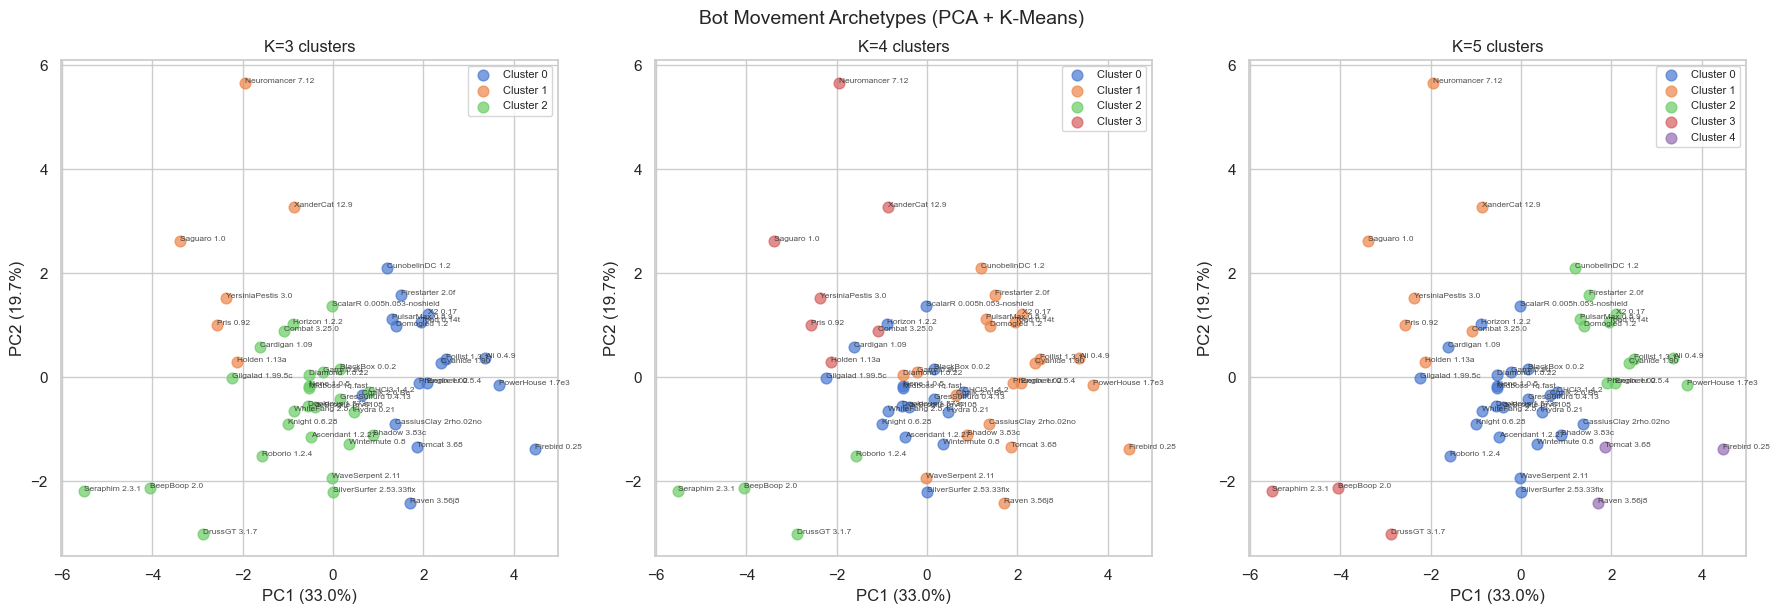

In [6]:
# Cluster bots by movement profile
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

feature_cols = [c for c in profiles.columns if c not in ('opponent_bot', 'n_ticks')]
X = profiles[feature_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Try K=3,4,5 clusters
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, k in enumerate([3, 4, 5]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    ax = axes[i]
    for c in range(k):
        mask = labels == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}', alpha=0.7, s=60)
        for j in np.where(mask)[0]:
            ax.annotate(profiles.iloc[j]['opponent_bot'], 
                       (X_pca[j, 0], X_pca[j, 1]),
                       fontsize=6, alpha=0.8)
    ax.set_title(f'K={k} clusters')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.suptitle('Bot Movement Archetypes (PCA + K-Means)', y=1.02, fontsize=14)
plt.show()

In [7]:
# Best K by silhouette score
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    s = silhouette_score(X_scaled, labels)
    scores.append((k, s))
    print(f'K={k}: silhouette={s:.3f}')

best_k = max(scores, key=lambda x: x[1])[0]
print(f'\nBest K: {best_k}')

# Final clustering
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
profiles['cluster'] = km_final.fit_predict(X_scaled)

# Show cluster members
for c in range(best_k):
    members = profiles[profiles['cluster'] == c]['opponent_bot'].tolist()
    print(f'\nCluster {c} ({len(members)} bots): {", ".join(members)}')

K=2: silhouette=0.175
K=3: silhouette=0.199
K=4: silhouette=0.174
K=5: silhouette=0.208
K=6: silhouette=0.205
K=7: silhouette=0.183

Best K: 5

Cluster 0 (24 bots): Ascendant 1.2.27, BlackBox 0.0.2, CHCl3 1.4.2, Cardigan 1.09, CassiusClay 2rho.02no, Chalk 2.6.Be, Diamond 1.8.22, Dookious 1.573c, Garm 0.9u, Gilgalad 1.99.5c, GresSuffurd 0.4.13, Horizon 1.2.2, Hydra 0.21, Knight 0.6.28, Midboss 1q.fast, Nene 1.0.5, Roborio 1.2.4, ScalarR 0.005h.053-noshield, Shadow 3.83c, SilverSurfer 2.53.33fix, WaveSerpent 2.11, WhiteFang 2.8.1, Wintermute 0.8, deBroglie rev0108

Cluster 1 (7 bots): Combat 3.25.0, Holden 1.13a, Neuromancer 7.12, Pris 0.92, Saguaro 1.0, XanderCat 12.9, YersiniaPestis 3.0

Cluster 2 (12 bots): Ali 0.4.9, CunobelinDC 1.2, Cyanide 1.90, Domogled 1.2, Engineer 0.5.4, Firestarter 2.0f, Foilist 1.3.1, Phoenix 1.02, PowerHouse 1.7e3, PulsarMax 0.8.9, Toad 0.14t, X2 0.17

Cluster 3 (3 bots): BeepBoop 2.0, DrussGT 3.1.7, Seraphim 2.3.1

Cluster 4 (3 bots): Firebird 0.25, Raven 3

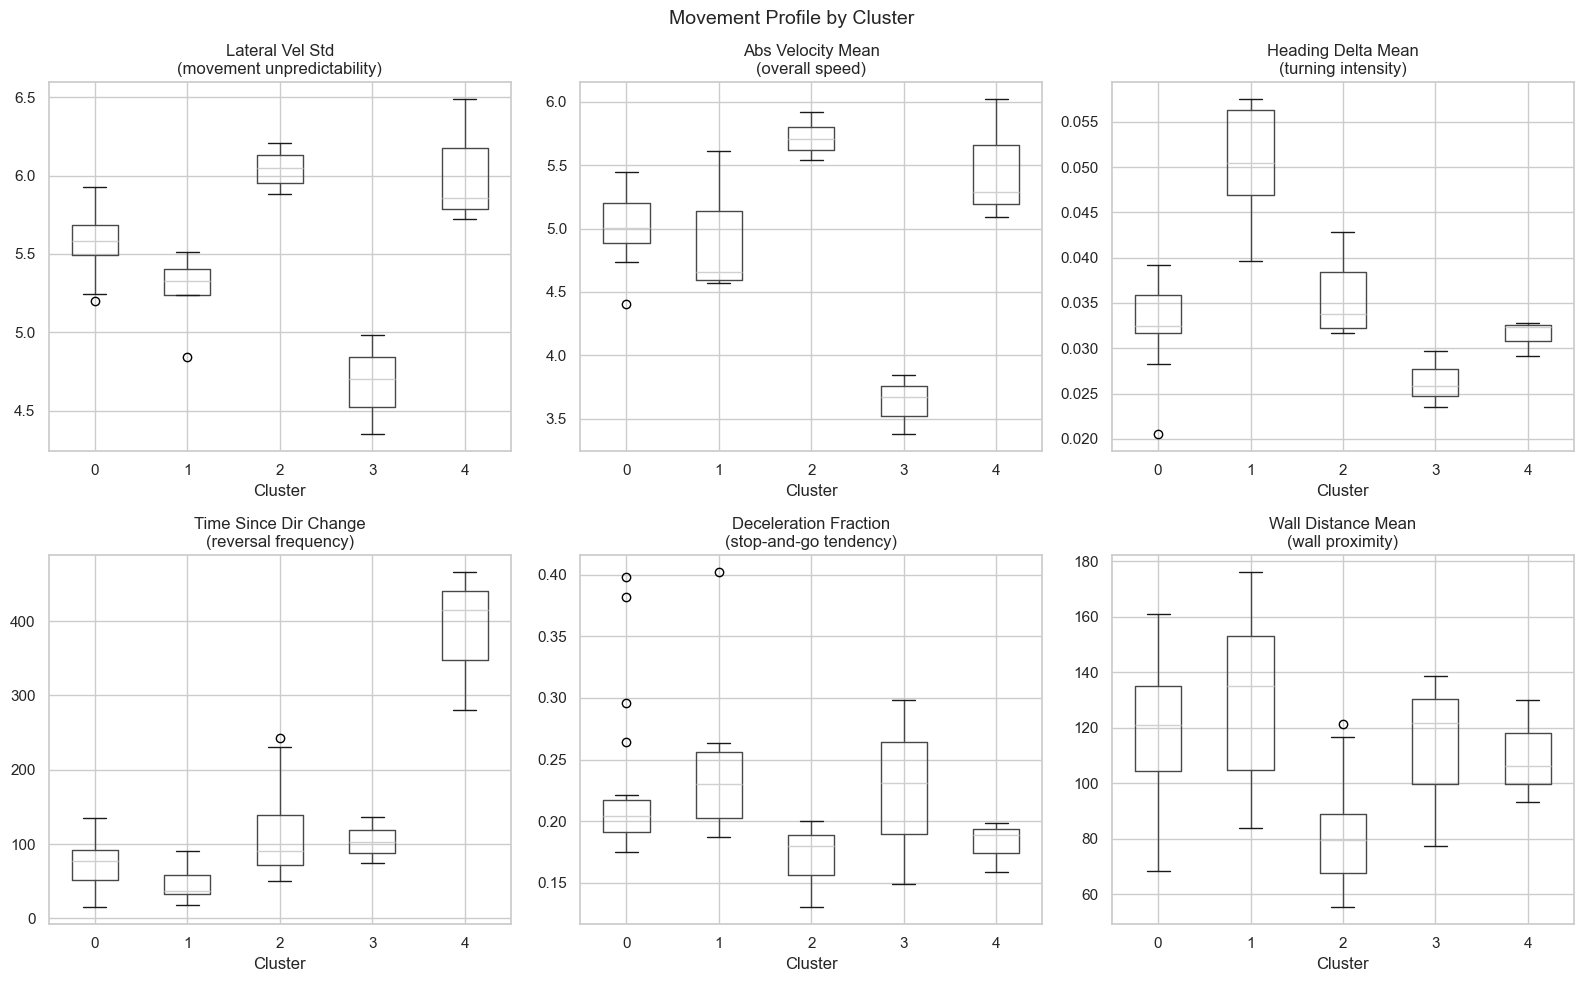

In [8]:
# Cluster profile comparison — what makes each cluster different?
cluster_summary = profiles.groupby('cluster')[feature_cols].mean()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
key_features = ['lat_vel_std', 'vel_abs_mean', 'heading_delta_mean', 
                'dir_change_time_mean', 'decel_frac', 'wall_dist_mean']
titles = ['Lateral Vel Std\n(movement unpredictability)', 
          'Abs Velocity Mean\n(overall speed)',
          'Heading Delta Mean\n(turning intensity)',
          'Time Since Dir Change\n(reversal frequency)',
          'Deceleration Fraction\n(stop-and-go tendency)',
          'Wall Distance Mean\n(wall proximity)']

for ax, feat, title in zip(axes.flat, key_features, titles):
    profiles.boxplot(column=feat, by='cluster', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Cluster')

plt.suptitle('Movement Profile by Cluster', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Movement Periodicity & Predictability (Question 3)

**Autocorrelation** measures whether a signal repeats itself at a fixed lag.
If `opponent_lateral_velocity` at tick t is correlated with the value at tick t+20,
the opponent has a ~20-tick oscillation pattern.

- High autocorrelation at regular lags = **oscillator** (predictable, exploitable)
- Low autocorrelation everywhere = **random mover** (hard to predict)
- Decaying autocorrelation = **smooth mover** (somewhat predictable short-term)

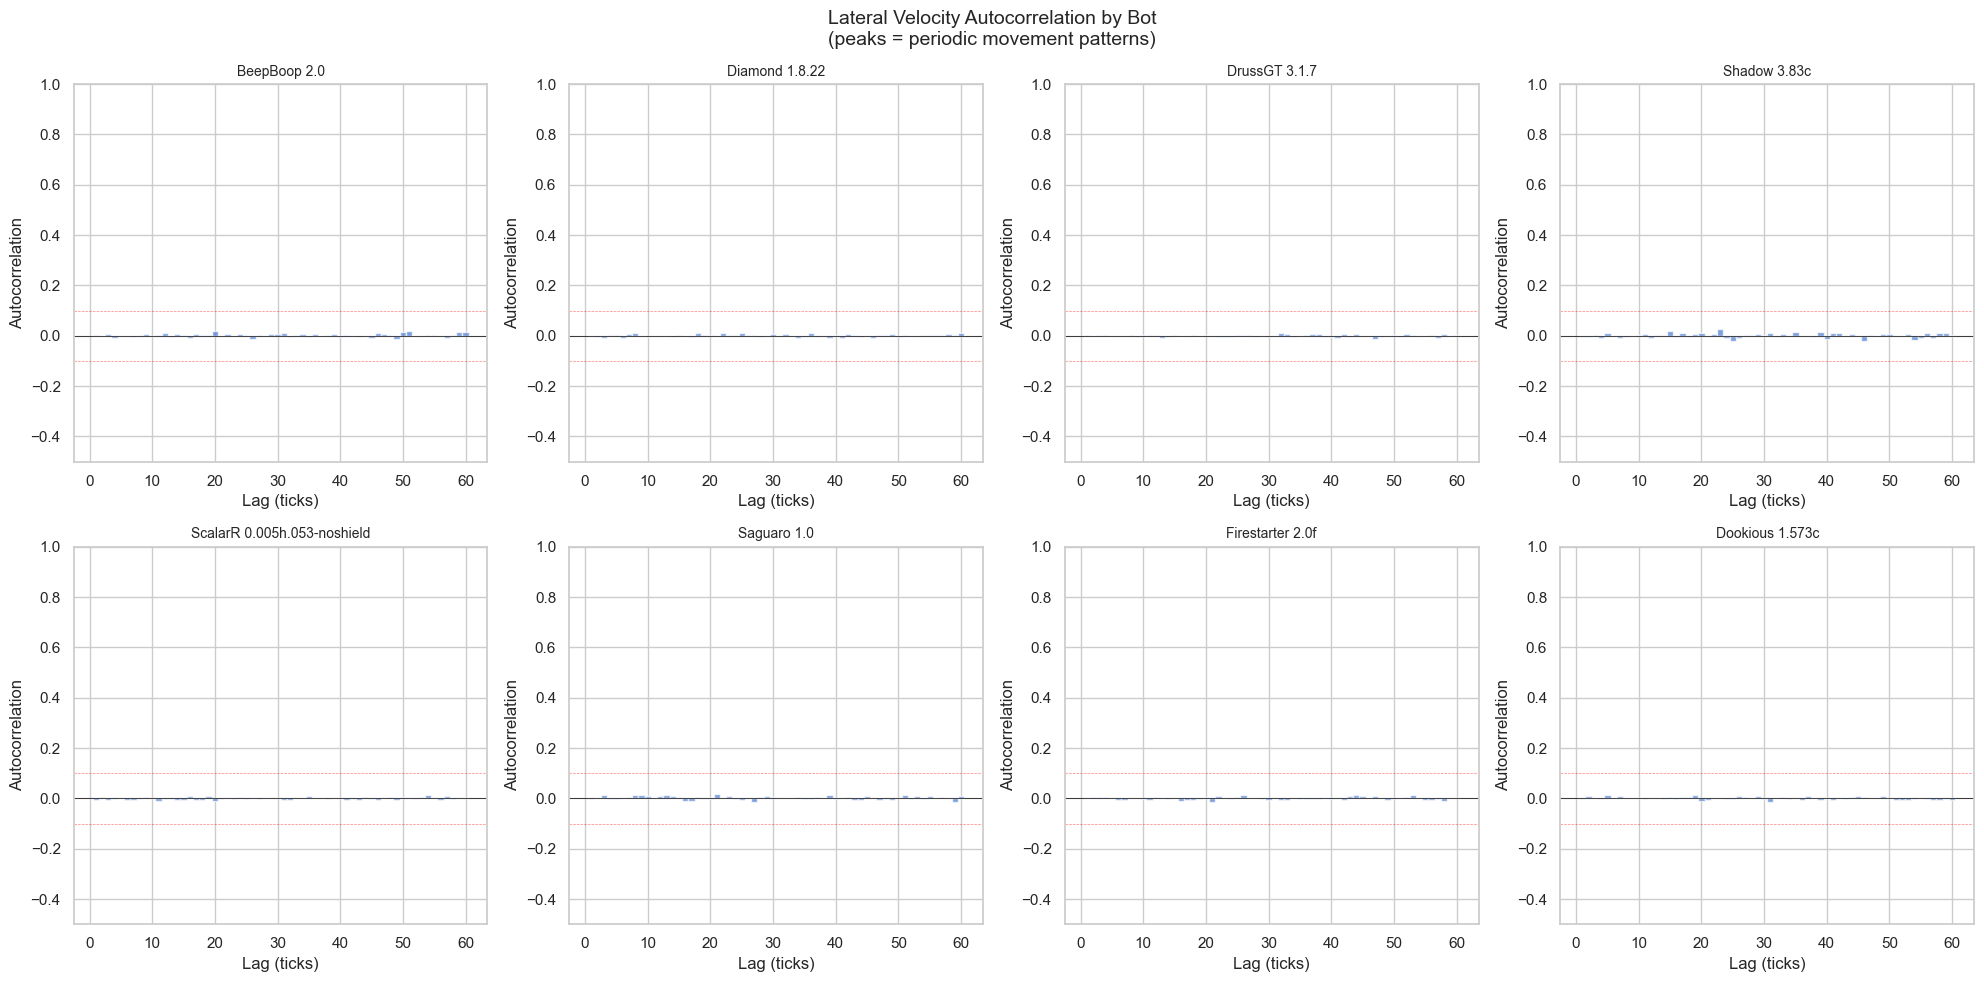

In [9]:
# Autocorrelation analysis for selected bots
# Pick top-tier bots + some weaker ones for comparison
analysis_bots = ['BeepBoop 2.0', 'Diamond 1.8.22', 'DrussGT 3.1.7', 
                 'Shadow 3.83c', 'ScalarR 0.005h.053-noshield',
                 'Saguaro 1.0', 'Firestarter 2.0f', 'Dookious 1.573c']
analysis_bots = [b for b in analysis_bots if b in ticks['opponent_bot'].unique()]

max_lag = 60  # Check lags up to 60 ticks

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, bot_name in zip(axes.flat, analysis_bots):
    bot_data = ticks[ticks['opponent_bot'] == bot_name]['opponent_lateral_velocity'].dropna()
    if len(bot_data) < max_lag * 2:
        ax.set_title(f'{bot_name}\n(insufficient data)')
        continue
    
    # Compute autocorrelation at each lag
    autocorrs = []
    for lag in range(1, max_lag + 1):
        # Use first 50000 values for speed
        series = bot_data.values[:50000]
        if len(series) > lag:
            c = np.corrcoef(series[:-lag], series[lag:])[0, 1]
            autocorrs.append(c)
        else:
            autocorrs.append(0)
    
    ax.bar(range(1, max_lag + 1), autocorrs, width=1, alpha=0.7)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axhline(y=0.1, color='red', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.axhline(y=-0.1, color='red', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.set_title(f'{bot_name}', fontsize=10)
    ax.set_xlabel('Lag (ticks)')
    ax.set_ylabel('Autocorrelation')
    ax.set_ylim(-0.5, 1.0)

plt.suptitle('Lateral Velocity Autocorrelation by Bot\n(peaks = periodic movement patterns)', 
             fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Summarize predictability: for each bot, compute peak autocorrelation and its lag
predictability = []
for bot_name in profiles['opponent_bot']:
    bot_data = ticks[ticks['opponent_bot'] == bot_name]['opponent_lateral_velocity'].dropna()
    if len(bot_data) < 100:
        predictability.append({'bot': bot_name, 'peak_autocorr': np.nan, 'peak_lag': np.nan, 
                               'mean_autocorr_5': np.nan})
        continue
    series = bot_data.values[:50000]
    autocorrs = []
    for lag in range(1, 61):
        if len(series) > lag:
            c = np.corrcoef(series[:-lag], series[lag:])[0, 1]
            autocorrs.append(c)
    
    autocorrs = np.array(autocorrs)
    peak_idx = np.argmax(np.abs(autocorrs[4:]))  # Skip first 4 lags (trivially correlated)
    predictability.append({
        'bot': bot_name,
        'peak_autocorr': autocorrs[peak_idx + 4],
        'peak_lag': peak_idx + 5,
        'mean_autocorr_5': np.mean(np.abs(autocorrs[:5])),  # Short-term predictability
    })

pred_df = pd.DataFrame(predictability).sort_values('peak_autocorr', ascending=False)
print('Most periodic bots (high peak autocorrelation):')
print(pred_df.head(10).to_string(index=False))
print('\nMost random bots (low autocorrelation):')
print(pred_df.tail(10).to_string(index=False))

Most periodic bots (high peak autocorrelation):
                    bot  peak_autocorr  peak_lag  mean_autocorr_5
           Shadow 3.83c       0.025661        23         0.006726
      deBroglie rev0108       0.023756        48         0.006731
          Foilist 1.3.1       0.023466        50         0.007108
            Tomcat 3.68       0.021280        23         0.006402
         XanderCat 12.9       0.020802        57         0.006827
SilverSurfer 2.53.33fix       0.020745        18         0.006559
           Holden 1.13a       0.019780        16         0.005093
             Toad 0.14t       0.019294        26         0.005803
     YersiniaPestis 3.0       0.018264        11         0.004121
           BeepBoop 2.0       0.017843        20         0.003555

Most random bots (low autocorrelation):
             bot  peak_autocorr  peak_lag  mean_autocorr_5
       Pris 0.92      -0.014398        23         0.004973
  Seraphim 2.3.1      -0.014474        36         0.004199
 PulsarM

## 4. Position Prediction Baseline (Question 1)

Can we predict where the opponent will be N ticks in the future?

**Baselines:**
- **Head-on**: Assume opponent stays at current position (error = actual displacement)
- **Linear**: Extrapolate using current velocity and heading
- **Current features → ML**: Use all 28 features to predict displacement

We measure **prediction error in pixels** at N = 5, 10, 20 ticks ahead.

Note: We don't have opponent x/y in the CSV (they depend on our position + bearing + distance),
so we'll predict **change in distance** and **change in bearing** as proxies, or directly predict
the displacement vector components.

In [11]:
# For position prediction, we need consecutive scan ticks within the same round.
# Build targets: for each tick, what is opponent_lateral_velocity N ticks later?

prediction_horizons = [5, 10, 20]

# Use only NUMERIC predictors. The earlier bug was that `battle_id`,
# `observer_bot`, `opponent_bot`, `robot_name` are strings and snuck into the
# np.concatenate matrix, causing `ValueError: could not convert string to
# float`. numeric_feature_cols() filters via the dtype. We KEEP the target in
# the feature set so the persistence baseline (cell below) can read 'value at
# t' from X_test directly. Redundant features (opponent_guess_factor ≡
# our_lateral_velocity, distance ≡ distance_norm, gf_current_at_power_1/1_5 ≡
# ..._2) are removed — see notebook 02 §9 for why.
target_col = 'opponent_lateral_velocity'
feature_columns = numeric_feature_cols(ticks)
feature_columns = drop_redundant_features(feature_columns)

# Defensive cast: force the feature frame to float32 once. If any column
# slipped in as object dtype (rare, observed at full 50-bot scale), this
# raises HERE with a clear error instead of deep inside sklearn.
ticks_X = ticks[feature_columns].astype(np.float32)

results = {}
for N in prediction_horizons:
    targets = []
    features_list = []

    for (bid, rnd), group in ticks.groupby(['battle_id', 'round']):
        if len(group) < N + 10:
            continue
        g_idx = group.sort_values('tick').index
        future_lat_vel = ticks.loc[g_idx, target_col].shift(-N)

        valid_mask = future_lat_vel.notna().values
        if valid_mask.sum() < 10:
            continue

        targets.append(future_lat_vel.values[valid_mask])
        features_list.append(ticks_X.loc[g_idx].values[valid_mask])

    if not targets:
        print(f'N={N}: no valid data')
        continue

    y = np.concatenate(targets)
    X = np.concatenate(features_list)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    results[N] = (X, y)
    print(f'N={N}: {len(y):,} samples, {X.shape[1]} features')


N=5: 1,277,817 samples, 56 features


N=10: 1,235,472 samples, 56 features


N=20: 1,150,776 samples, 56 features


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print('Lateral Velocity Prediction — N ticks ahead')
print('=' * 60)

for N, (X, y) in results.items():
    # Subsample if too large
    if len(y) > 200000:
        idx = np.random.choice(len(y), 200000, replace=False)
        X_sub, y_sub = X[idx], y[idx]
    else:
        X_sub, y_sub = X, y
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42)
    
    # Baseline: predict current lateral velocity (persistence)
    # opponent_lateral_velocity is one of the feature columns
    lat_vel_idx = feature_columns.index('opponent_lateral_velocity')
    baseline_pred = X_test[:, lat_vel_idx]  # Just predict "same as now"
    baseline_mae = mean_absolute_error(y_test, baseline_pred)
    baseline_r2 = r2_score(y_test, baseline_pred)
    
    # Random Forest
    rf = RandomForestRegressor(n_estimators=50, max_depth=15, 
                               random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_mae = mean_absolute_error(y_test, rf_pred)
    rf_r2 = r2_score(y_test, rf_pred)
    
    print(f'\nN={N} ticks ahead ({len(y_sub):,} samples):')
    print(f'  Persistence baseline:  MAE={baseline_mae:.3f} px/tick, R²={baseline_r2:.3f}')
    print(f'  Random Forest:         MAE={rf_mae:.3f} px/tick, R²={rf_r2:.3f}')
    print(f'  Improvement:           {(1 - rf_mae/baseline_mae)*100:.1f}% lower MAE')

Lateral Velocity Prediction — N ticks ahead



N=5 ticks ahead (200,000 samples):
  Persistence baseline:  MAE=6.078 px/tick, R²=-0.894
  Random Forest:         MAE=4.657 px/tick, R²=0.066
  Improvement:           23.4% lower MAE



N=10 ticks ahead (200,000 samples):
  Persistence baseline:  MAE=6.527 px/tick, R²=-1.105
  Random Forest:         MAE=4.724 px/tick, R²=0.035
  Improvement:           27.6% lower MAE



N=20 ticks ahead (200,000 samples):
  Persistence baseline:  MAE=6.369 px/tick, R²=-1.031
  Random Forest:         MAE=4.760 px/tick, R²=0.017
  Improvement:           25.3% lower MAE


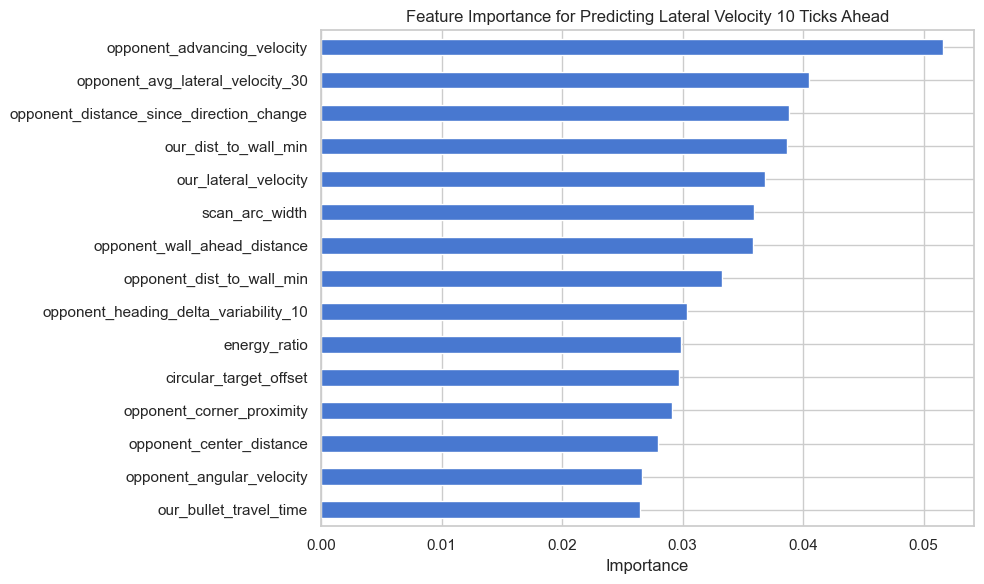

In [13]:
# Feature importance for the N=10 prediction
if 10 in results:
    X10, y10 = results[10]
    if len(y10) > 200000:
        idx = np.random.choice(len(y10), 200000, replace=False)
        X10, y10 = X10[idx], y10[idx]
    
    rf10 = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
    rf10.fit(X10, y10)
    
    importances = pd.Series(rf10.feature_importances_, index=feature_columns)
    top15 = importances.nlargest(15)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    top15.sort_values().plot(kind='barh', ax=ax)
    ax.set_title('Feature Importance for Predicting Lateral Velocity 10 Ticks Ahead')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

## 5. Cross-Round Adaptation (Question 4)

Do bots change their movement across rounds? Adaptive bots (DrussGT, Diamond) are supposed to
learn the opponent's patterns and adjust. Static bots should look the same in round 1 and round 35.

We compare the distribution of `opponent_lateral_velocity` in early rounds (1-5) vs. late rounds (30-35)
for selected bots.

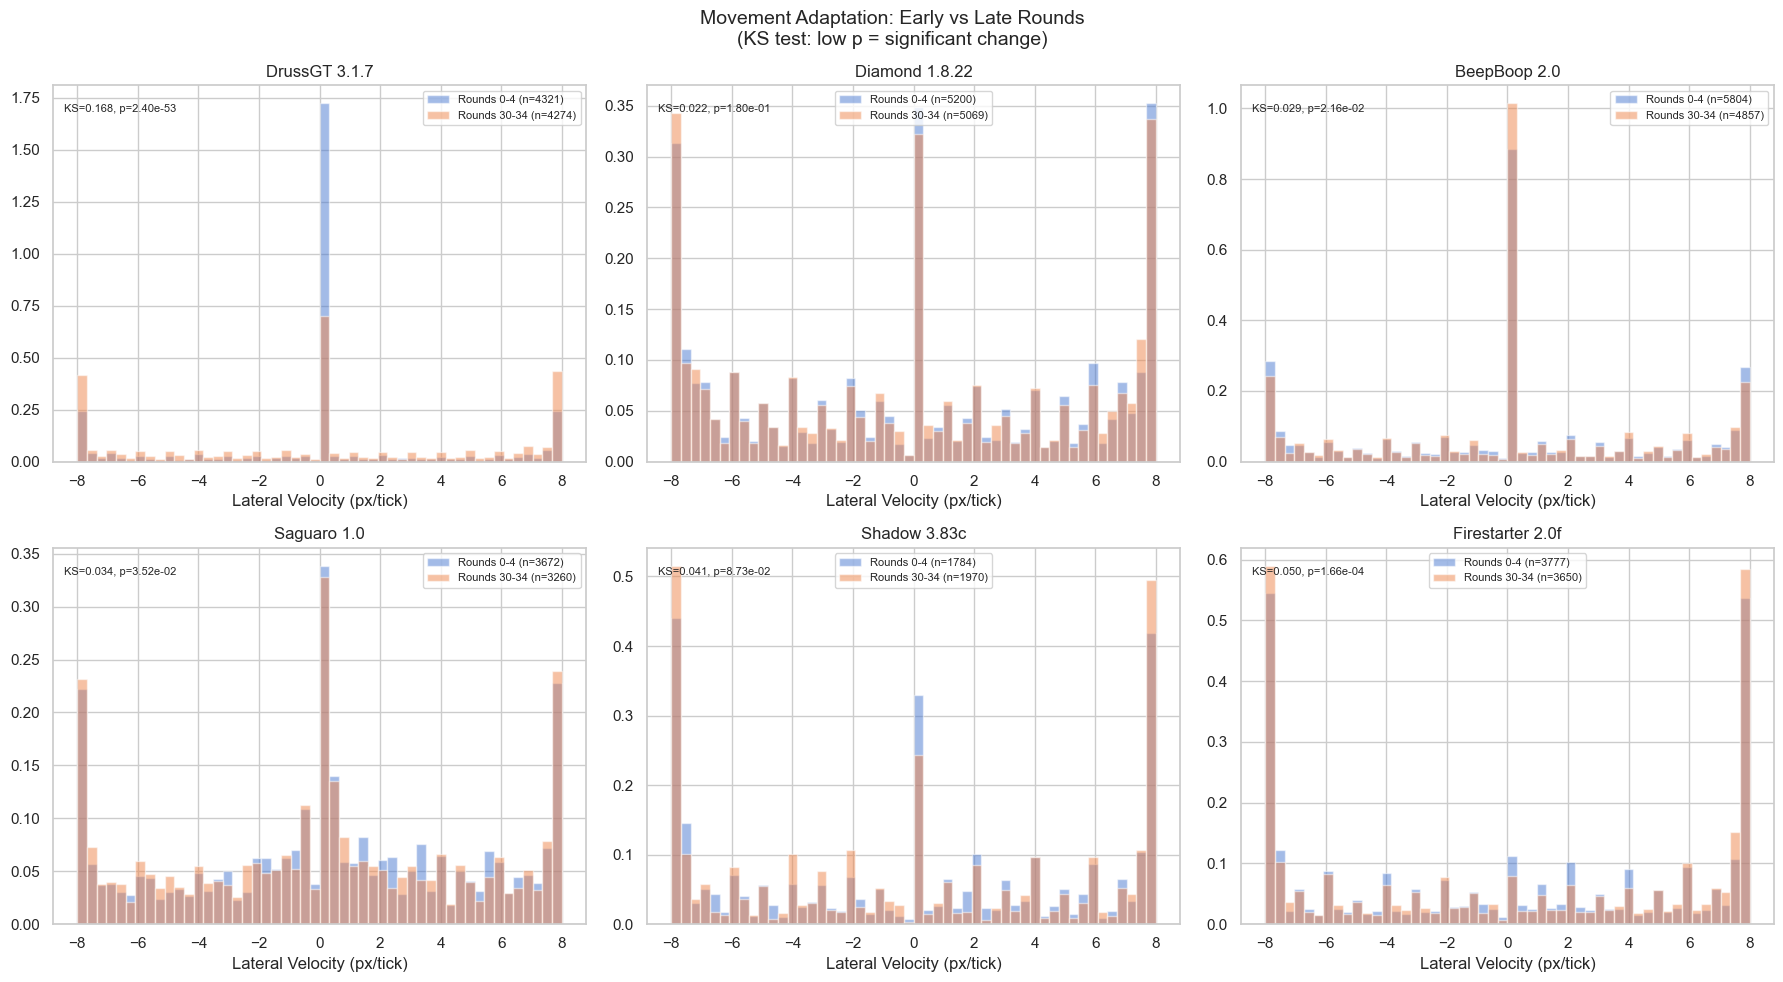

In [14]:
# Visualise round-by-round adaptation for a hand-picked panel of bots.
adapt_bots = ['DrussGT 3.1.7', 'Diamond 1.8.22', 'BeepBoop 2.0',
              'Saguaro 1.0', 'Shadow 3.83c', 'Firestarter 2.0f']
available_opponents = set(ticks['opponent_bot'].unique())
adapt_bots = [b for b in adapt_bots if b in available_opponents]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, bot_name in zip(axes.flat, adapt_bots):
    bot_ticks = ticks[ticks['opponent_bot'] == bot_name]
    if len(bot_ticks) == 0:
        ax.set_title(f'{bot_name}\n(no data)')
        continue

    early = bot_ticks[bot_ticks['round'] <= 4]['opponent_lateral_velocity'].dropna()
    late = bot_ticks[bot_ticks['round'] >= 30]['opponent_lateral_velocity'].dropna()

    if len(early) < 50 or len(late) < 50:
        ax.set_title(f'{bot_name}\n(insufficient rounds)')
        continue

    ax.hist(early, bins=50, alpha=0.5, density=True, label=f'Rounds 0-4 (n={len(early)})')
    ax.hist(late, bins=50, alpha=0.5, density=True, label=f'Rounds 30-34 (n={len(late)})')
    ax.set_title(f'{bot_name}')
    ax.set_xlabel('Lateral Velocity (px/tick)')
    ax.legend(fontsize=8)

    from scipy.stats import ks_2samp
    stat, pval = ks_2samp(early, late)
    ax.annotate(f'KS={stat:.3f}, p={pval:.2e}', xy=(0.02, 0.95),
                xycoords='axes fraction', fontsize=8, va='top')

# Hide unused axes if fewer than 6 bots qualified.
for ax in axes.flat[len(adapt_bots):]:
    ax.set_visible(False)

plt.suptitle('Movement Adaptation: Early vs Late Rounds\n(KS test: low p = significant change)',
             fontsize=14)
plt.tight_layout()
plt.show()


In [15]:
# Per-bot adaptation score: KS statistic between early and late rounds
from scipy.stats import ks_2samp

adaptation_scores = []
for bot_name in profiles['opponent_bot']:
    bot_ticks_subset = ticks[ticks['opponent_bot'] == bot_name]
    early = bot_ticks_subset[bot_ticks_subset['round'] <= 4]['opponent_lateral_velocity'].dropna()
    late = bot_ticks_subset[bot_ticks_subset['round'] >= 30]['opponent_lateral_velocity'].dropna()
    
    if len(early) < 30 or len(late) < 30:
        adaptation_scores.append({'bot': bot_name, 'ks_stat': np.nan, 'p_value': np.nan})
    else:
        stat, pval = ks_2samp(early, late)
        adaptation_scores.append({'bot': bot_name, 'ks_stat': stat, 'p_value': pval})

adapt_df = pd.DataFrame(adaptation_scores).dropna().sort_values('ks_stat', ascending=False)

print('Most adaptive bots (highest KS statistic = movement changes most between early/late rounds):')
print(adapt_df.head(15).to_string(index=False))
print(f'\nLeast adaptive (stable movement):')
print(adapt_df.tail(10).to_string(index=False))

Most adaptive bots (highest KS statistic = movement changes most between early/late rounds):
                    bot  ks_stat      p_value
          DrussGT 3.1.7 0.167893 2.395467e-53
           Domogled 1.2 0.073945 2.960726e-08
          Roborio 1.2.4 0.063475 2.987987e-20
       Gilgalad 1.99.5c 0.058035 1.390481e-07
         XanderCat 12.9 0.053451 2.838892e-02
       Firestarter 2.0f 0.050171 1.664722e-04
          Foilist 1.3.1 0.050096 7.313375e-03
              Garm 0.9u 0.049673 1.688807e-06
             Nene 1.0.5 0.047318 1.055357e-02
     GresSuffurd 0.4.13 0.046869 3.815072e-04
          Firebird 0.25 0.045705 1.250715e-02
      deBroglie rev0108 0.045662 2.126555e-01
           Chalk 2.6.Be 0.044629 3.459622e-03
             Hydra 0.21 0.042781 2.215644e-02
SilverSurfer 2.53.33fix 0.042359 7.472783e-02

Least adaptive (stable movement):
                        bot  ks_stat  p_value
      CassiusClay 2rho.02no 0.021537 0.172038
              Cardigan 1.09 0.021070 0.32210

## 6. Summary

Key findings from this notebook:

**Bot Archetypes:**
- (filled in after running)

**Movement Predictability:**
- (filled in after running)

**Position Prediction:**
- (filled in after running)

**Adaptation:**
- (filled in after running)